# 03 — Feature Engineering

Ky notebook ngarkon dataset-in e pastruar dhe shton features të reja.
Të gjitha features krijohen mbi dataset-in e plotë **para split-it**, me përjashtim të features që kërkojnë KMeans dhe lat/long bins — ato do mësohen vetëm nga training set në notebook 04.

## 1. Importet dhe ngarkimi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_cleaned = pd.read_csv("../../data/processed/data_cleaned.csv")
print("Shape:", data_cleaned.shape)
data_cleaned.head()

Shape: (21577, 24)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age_at_sale,was_renovated,years_since_renovation
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,98178,47.5112,-122.257,1340,5650,2014,10,59,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,98125,47.7210,-122.319,1690,7639,2014,12,63,1,23
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,98028,47.7379,-122.233,2720,8062,2015,2,82,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,98136,47.5208,-122.393,1360,5000,2014,12,49,0,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,98074,47.6168,-122.045,1800,7503,2015,2,28,0,0


## 2. Feature binare: `has_basement`

In [2]:
data_cleaned["has_basement"] = (data_cleaned["sqft_basement"] > 0).astype(int)
print(data_cleaned["has_basement"].value_counts())
data_cleaned[["sqft_basement", "has_basement"]].head()

has_basement
0    13103
1     8474
Name: count, dtype: int64


,sqft_basement,has_basement
0,0,0
1,400,1
2,0,0
3,910,1
4,0,0


## 3. Konfirmimi i features kohore

U krijuan në cleaning: `sale_year`, `sale_month`, `house_age_at_sale`, `was_renovated`, `years_since_renovation`.

In [3]:
new_features = ["sale_year","sale_month","house_age_at_sale","was_renovated","years_since_renovation","has_basement"]
print("Features të reja:")
print(data_cleaned[new_features].describe().round(2))
print(f"\nDataset: {data_cleaned.shape[0]} rreshta, {data_cleaned.shape[1]} kolona")

Features të reja:
       sale_year  sale_month  house_age_at_sale  was_renovated  \
count   21577.00    21577.00           21577.00       21577.00   
mean     2014.32        6.57              43.34           0.04   
std         0.47        3.12              29.36           0.20   
min      2014.00        1.00               0.00           0.00   
25%      2014.00        4.00              18.00           0.00   
50%      2014.00        6.00              40.00           0.00   
75%      2015.00        9.00              63.00           0.00   
max      2015.00       12.00             115.00           1.00   

       years_since_renovation  has_basement  
count                21577.00      21577.00  
mean                     0.78          0.39  
std                      4.90          0.49  
min                      0.00          0.00  
25%                      0.00          0.00  
50%                      0.00          0.00  
75%                      0.00          1.00  
max                

## 4. Analiza e korrelacionit

Shikon cilat features kanë lidhje të fortë me `price` — informacion i dobishëm para modelimit.

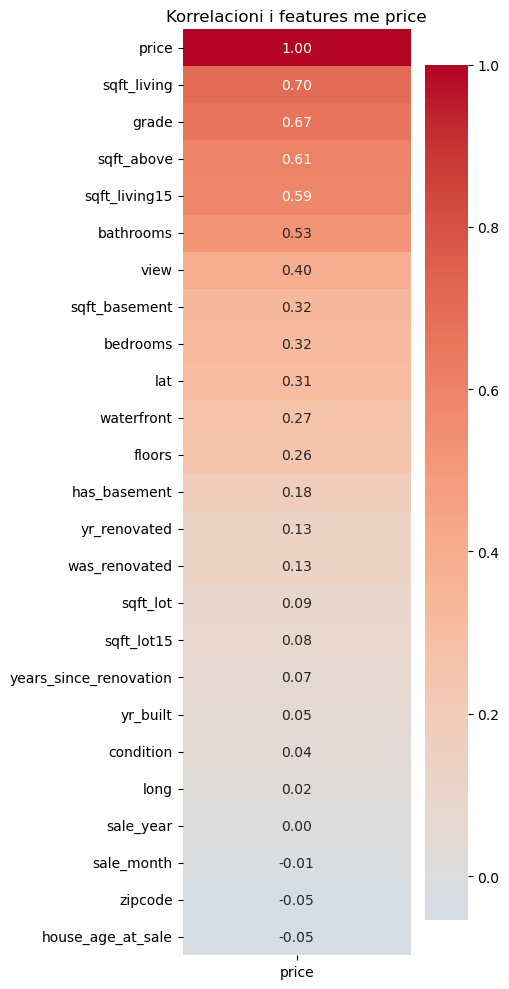

In [4]:
numeric_cols = data_cleaned.select_dtypes(include=[np.number]).columns
corr = data_cleaned[numeric_cols].corr()
price_corr = corr[["price"]].sort_values(by="price", ascending=False)

plt.figure(figsize=(5, 10))
sns.heatmap(price_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Korrelacioni i features me price")
plt.tight_layout()
plt.show()

## 5. Vizualizime shtesë: price vs features kryesore

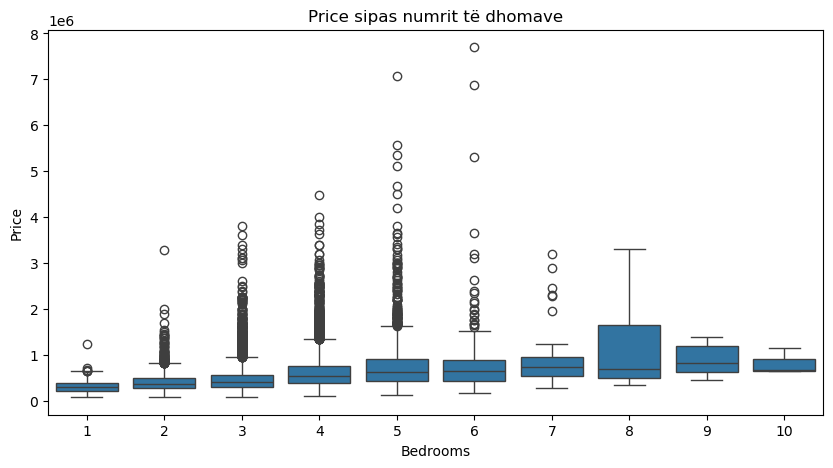

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_cleaned, x="bedrooms", y="price")
plt.title("Price sipas numrit të dhomave")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

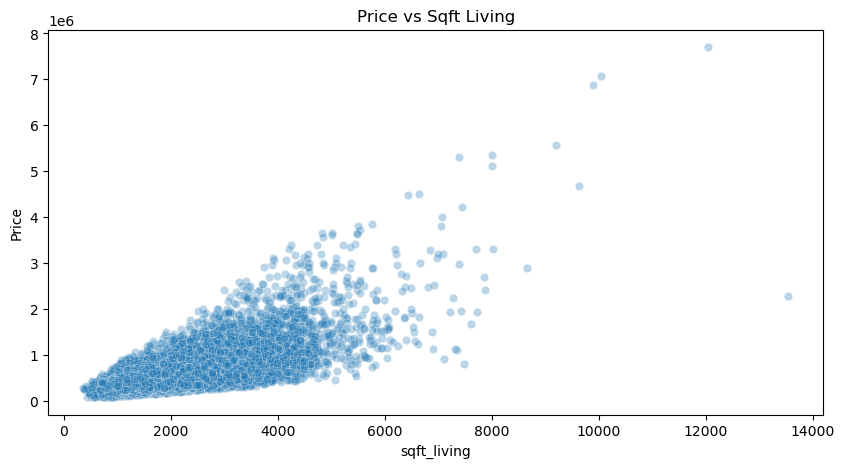

In [6]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data_cleaned, x="sqft_living", y="price", alpha=0.3)
plt.title("Price vs Sqft Living")
plt.xlabel("sqft_living")
plt.ylabel("Price")
plt.show()

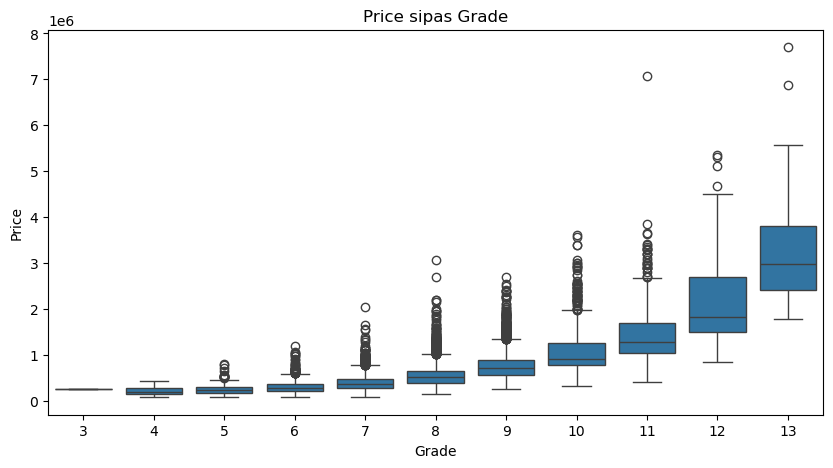

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_cleaned, x="grade", y="price")
plt.title("Price sipas Grade")
plt.xlabel("Grade")
plt.ylabel("Price")
plt.show()

## 6. Ruajtja

Dataset-i me features të reja kalon te `04_scaling_split.ipynb`.

In [8]:
data_cleaned.to_csv("../../data/processed/data_featured.csv", index=False)
print("Shape finale:", data_cleaned.shape)
print("Kolonat:", list(data_cleaned.columns))
print("Skedari i ruajtur: ../../data/processed/data_featured.csv")

Shape finale: (21577, 25)
Kolonat: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'house_age_at_sale', 'was_renovated', 'years_since_renovation', 'has_basement']
Skedari i ruajtur: ../../data/processed/data_featured.csv
